# Signal Generator Demonstration

This notebook demonstrates the 4 signal generators:
- GSM (2G)
- UMTS (3G)
- LTE (4G)
- 5G NR (5G)

For each generator, we show:
- Time-domain waveform
- Frequency spectrum
- Constellation diagram (where applicable)
- Signal properties (PAPR, bandwidth, power)

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt

from run_gsm import generate_gsm_signal
from run_umts import generate_umts_signal
from run_lte import generate_lte_signal
from run_5g import generate_5g_signal

In [2]:
def plot_signal_analysis(signal, sample_rate, title):
    """
    Plot comprehensive signal analysis.
    
    Args:
        signal: Complex signal tensor
        sample_rate: Sampling rate in Hz
        title: Plot title
    """
    # Convert to numpy
    signal_np = signal.cpu().numpy()
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # Time domain - magnitude
    t = np.arange(len(signal_np)) / sample_rate * 1000  # in ms
    axes[0, 0].plot(t[:1000], np.abs(signal_np[:1000]))
    axes[0, 0].set_xlabel('Time (ms)')
    axes[0, 0].set_ylabel('Magnitude')
    axes[0, 0].set_title('Time Domain (first 1000 samples)')
    axes[0, 0].grid(True)
    
    # Frequency spectrum
    spectrum = np.fft.fftshift(np.fft.fft(signal_np))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(signal_np), 1/sample_rate)) / 1e6  # MHz
    power_spectrum_db = 20 * np.log10(np.abs(spectrum) + 1e-12)
    
    axes[0, 1].plot(freqs, power_spectrum_db)
    axes[0, 1].set_xlabel('Frequency (MHz)')
    axes[0, 1].set_ylabel('Power (dB)')
    axes[0, 1].set_title('Frequency Spectrum')
    axes[0, 1].grid(True)
    
    # Constellation diagram
    # Downsample for visibility
    step = max(1, len(signal_np) // 2000)
    axes[1, 0].scatter(signal_np[::step].real, signal_np[::step].imag, alpha=0.3, s=1)
    axes[1, 0].set_xlabel('In-phase')
    axes[1, 0].set_ylabel('Quadrature')
    axes[1, 0].set_title('Constellation Diagram')
    axes[1, 0].grid(True)
    axes[1, 0].axis('equal')
    
    # Instantaneous power
    inst_power = np.abs(signal_np) ** 2
    axes[1, 1].plot(t[:1000], 10 * np.log10(inst_power[:1000] + 1e-12))
    axes[1, 1].set_xlabel('Time (ms)')
    axes[1, 1].set_ylabel('Power (dB)')
    axes[1, 1].set_title('Instantaneous Power')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()


def print_signal_properties(metadata):
    """
    Print signal properties from metadata.
    
    Args:
        metadata: Signal metadata dictionary
    """
    print("\nSignal Properties:")
    print("-" * 50)
    for key, value in metadata.items():
        if key == 'validation':
            print("Validation Metrics:")
            for vkey, vvalue in value.items():
                print(f"  {vkey}: {vvalue}")
        else:
            print(f"{key}: {value}")
    print("-" * 50)

## 1. GSM (2G) Signal


Signal Properties:
--------------------------------------------------
standard: GSM
modulation: GMSK
bit_rate: 270833
sample_rate: 2166000.0
carrier_freq: 0.0
duration_ms: 10.0
num_bits: 2708
power_dbm: 0.0
snr_db: None
Validation Metrics:
  power_avg_dbm: 4.3433309093538334e-12
  power_peak_dbm: 4.3433309093538334e-12
  papr_db: 0.0
  bandwidth_hz: 200000.0
  duration_ms: 8.751615881809787
  num_samples: 18956
--------------------------------------------------


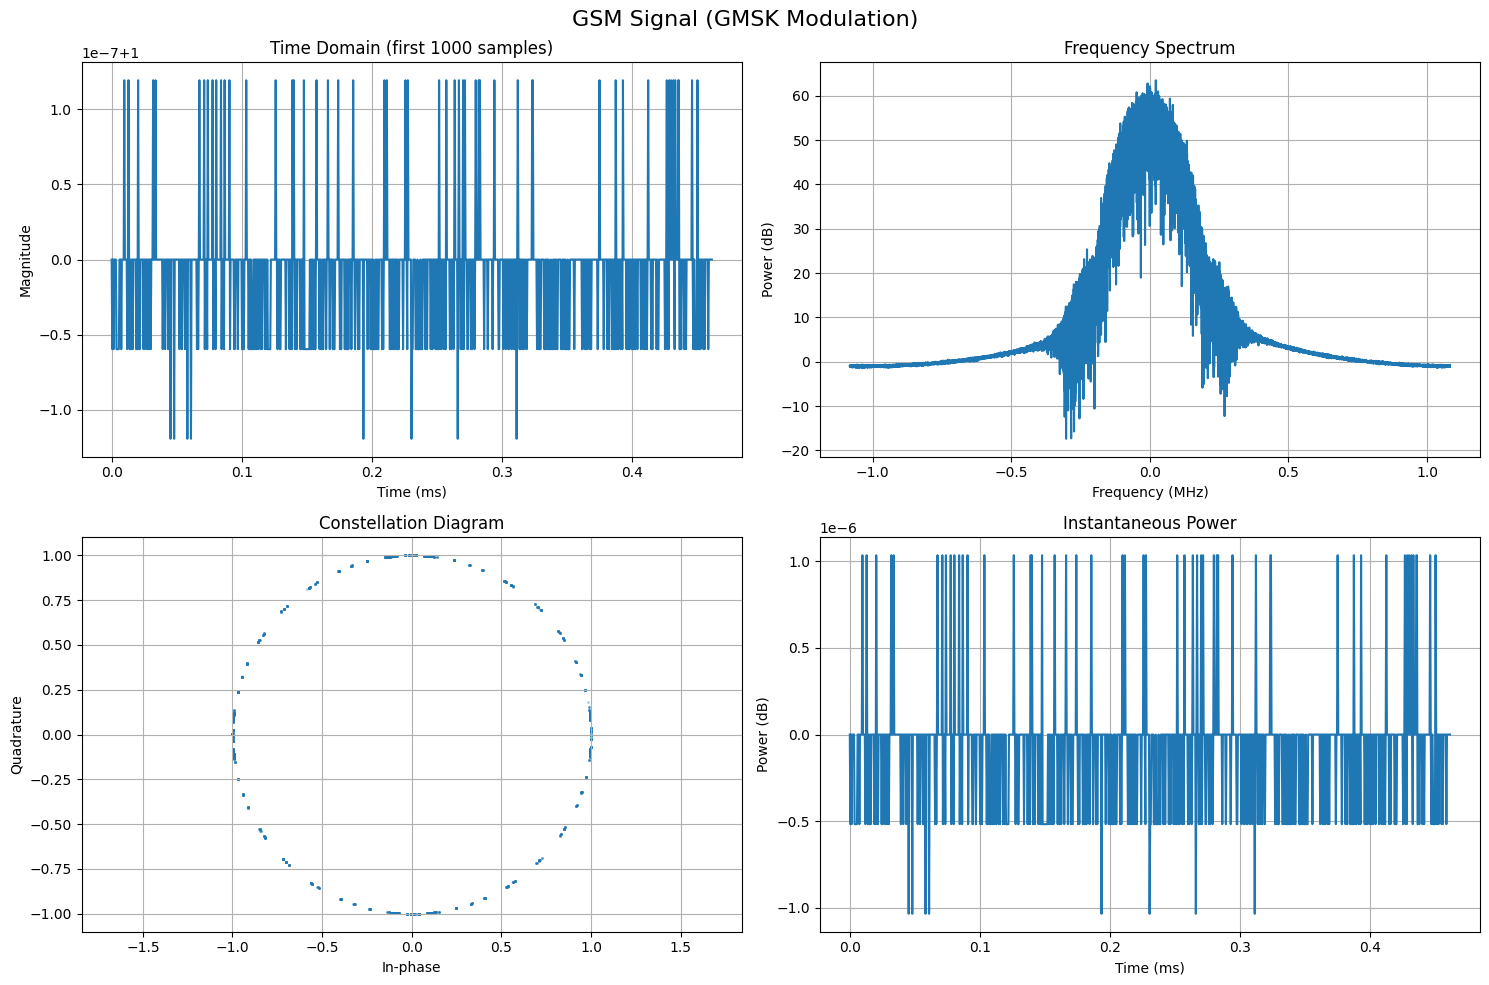

In [3]:
# Generate GSM signal
gsm_result = generate_gsm_signal(
    duration_ms=10.0,
    sample_rate=2.166e6,
    carrier_freq=0.0,  # Baseband
    power_dbm=0.0,
    device='cpu'
)

print_signal_properties(gsm_result['metadata'])
plot_signal_analysis(
    gsm_result['signal'],
    gsm_result['metadata']['sample_rate'],
    'GSM Signal (GMSK Modulation)'
)

## 2. UMTS (3G) Signal


Signal Properties:
--------------------------------------------------
standard: UMTS
modulation: QPSK with W-CDMA
chip_rate: 3840000.0
spreading_factor: 16
symbol_rate: 240000.0
bit_rate: 480000.0
sample_rate: 15360000.0
carrier_freq: 0.0
duration_ms: 10.0
num_symbols: 2400
scrambling_code: 0
power_dbm: 0.0
snr_db: None
Validation Metrics:
  power_avg_dbm: -7.765747762347328e-07
  power_peak_dbm: 5.2186872303896195
  papr_db: 5.218688006967431
  bandwidth_hz: 5000000.0
  duration_ms: 10.0
  num_samples: 153600
--------------------------------------------------


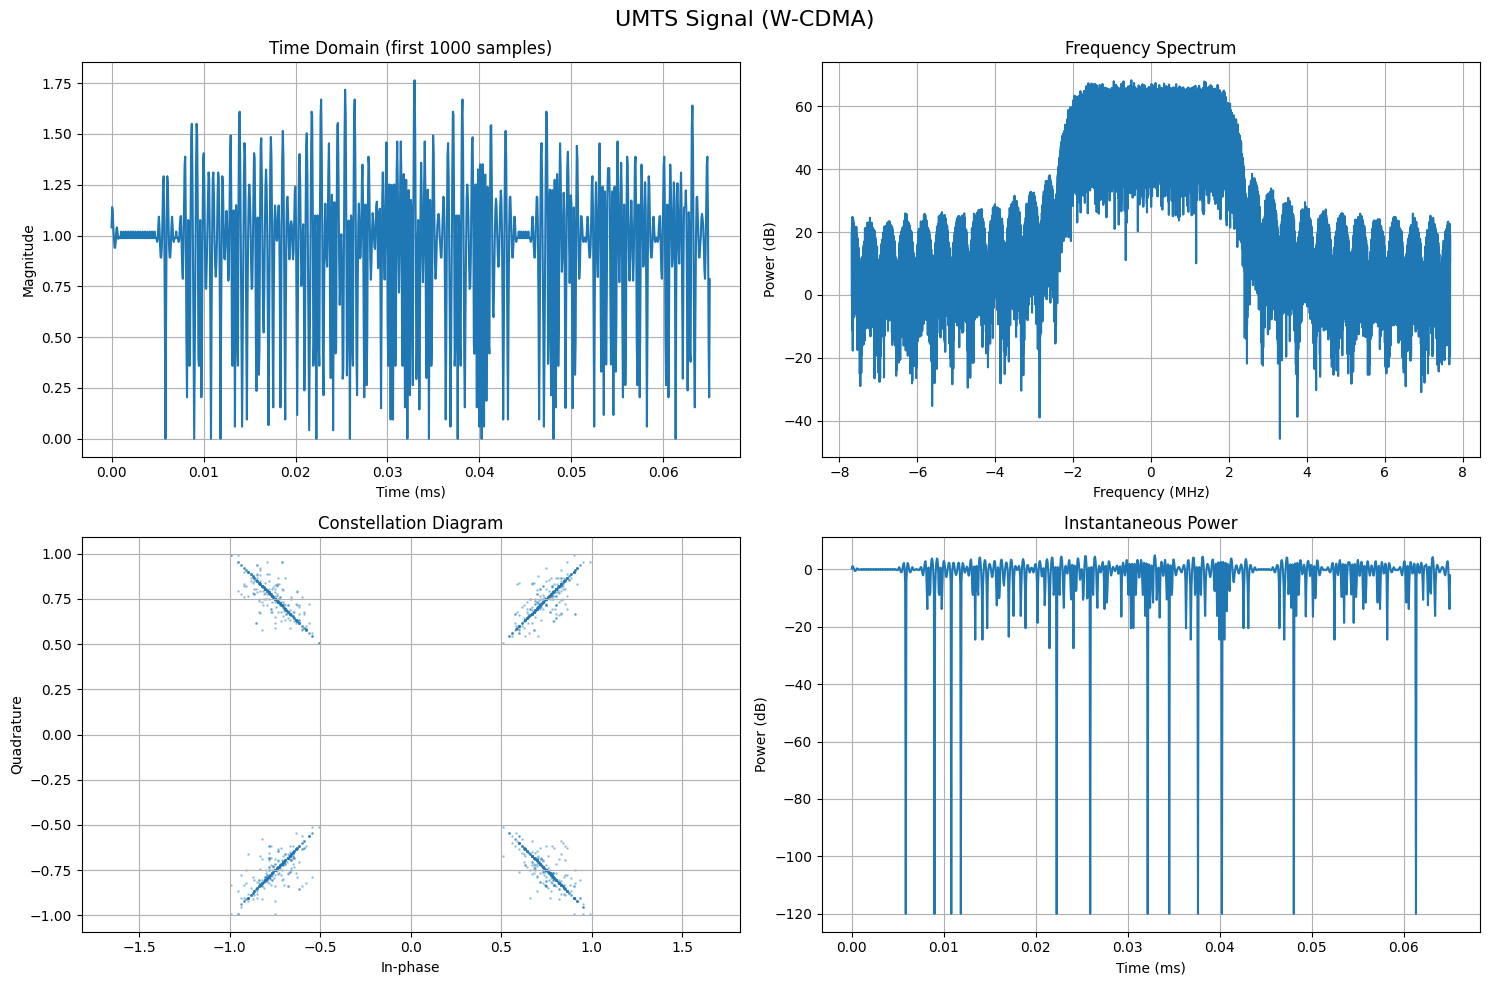

In [4]:
# Generate UMTS signal
umts_result = generate_umts_signal(
    duration_ms=10.0,
    spreading_factor=16,
    sample_rate=15.36e6,
    carrier_freq=0.0,
    power_dbm=0.0,
    device='cpu'
)

print_signal_properties(umts_result['metadata'])
plot_signal_analysis(
    umts_result['signal'],
    umts_result['metadata']['sample_rate'],
    'UMTS Signal (W-CDMA)'
)

## 3. LTE (4G) Signal


Signal Properties:
--------------------------------------------------
standard: LTE
modulation: QPSK
bandwidth_mhz: 10.0
num_rbs: 50
fft_size: 1024
sample_rate: 15360000.0
carrier_freq: 0.0
duration_ms: 10.0
num_subframes: 10
power_dbm: 0.0
snr_db: None
Validation Metrics:
  power_avg_dbm: -5.177150544443307e-07
  power_peak_dbm: 11.481314487896961
  papr_db: 11.481315005616048
  bandwidth_hz: 9000000
  duration_ms: 10.0
  num_samples: 153600
--------------------------------------------------


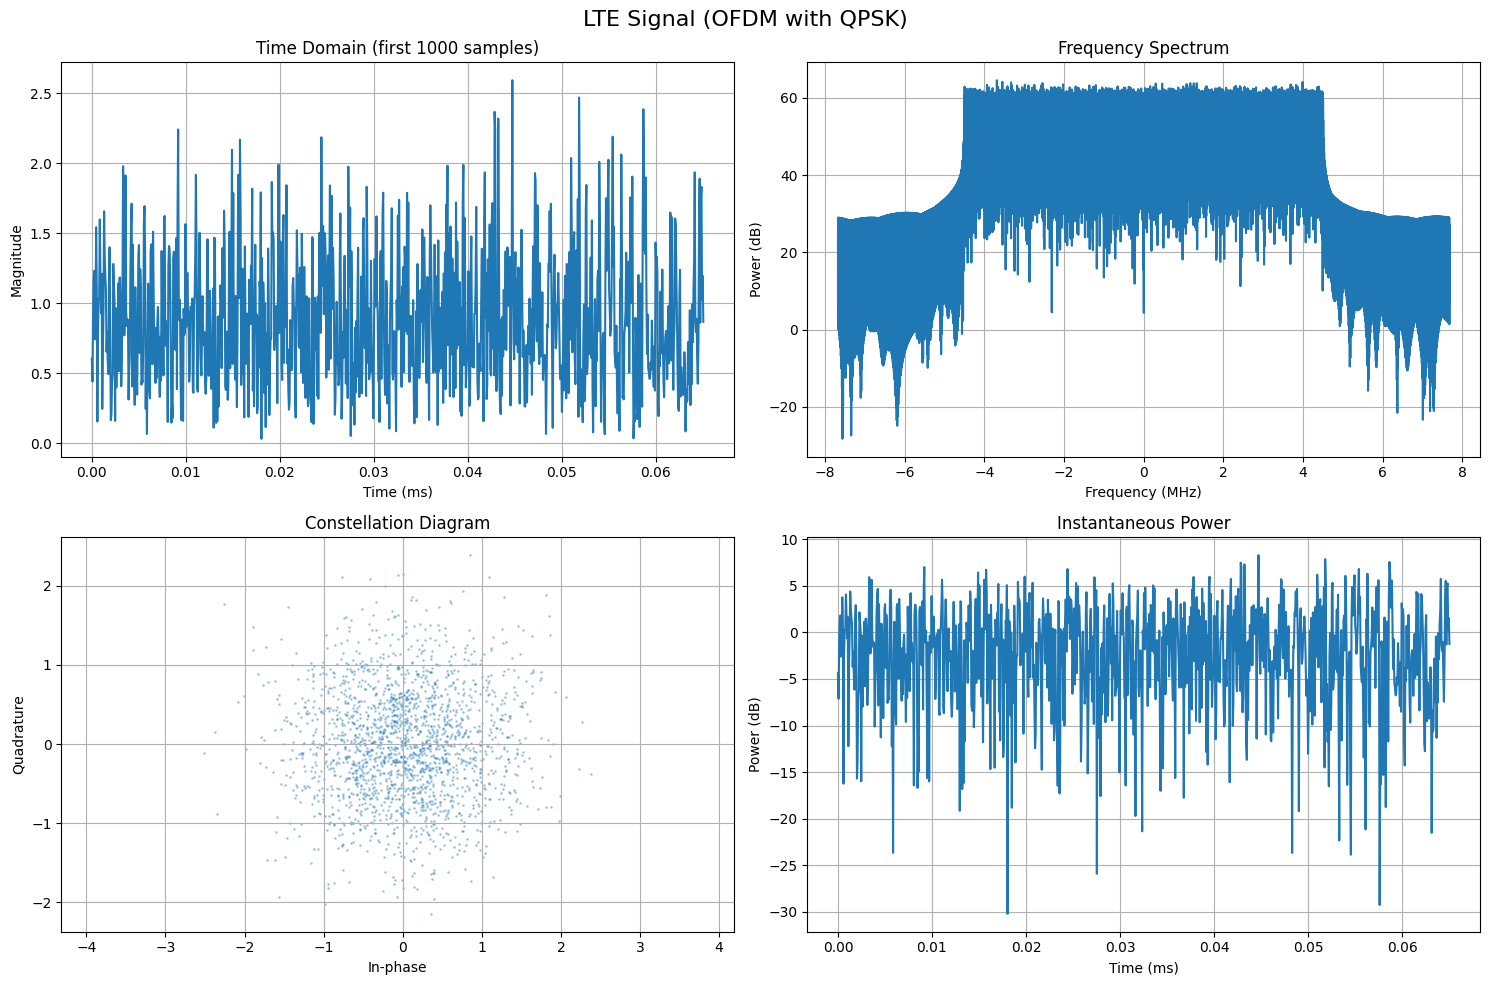

In [5]:
# Generate LTE signal
lte_result = generate_lte_signal(
    duration_ms=10.0,
    bandwidth_mhz=10.0,
    modulation_scheme='QPSK',
    carrier_freq=0.0,
    power_dbm=0.0,
    device='cpu'
)

print_signal_properties(lte_result['metadata'])
plot_signal_analysis(
    lte_result['signal'],
    lte_result['metadata']['sample_rate'],
    'LTE Signal (OFDM with QPSK)'
)

## 4. 5G NR (5G) Signal


Signal Properties:
--------------------------------------------------
standard: 5G NR
modulation: QPSK
numerology: 1
subcarrier_spacing_khz: 30.0
bandwidth_mhz: 100.0
num_rbs: 273
fft_size: 4096
sample_rate: 122880000
carrier_freq: 0.0
duration_ms: 10.0
num_slots: 20
slot_duration_ms: 0.5
add_dmrs: True
power_dbm: 0.0
snr_db: None
Validation Metrics:
  power_avg_dbm: -5.177150544443307e-07
  power_peak_dbm: 11.384698121780424
  papr_db: 11.384698639499504
  bandwidth_hz: 98280000
  duration_ms: 9.985026041666666
  num_samples: 1226960
--------------------------------------------------


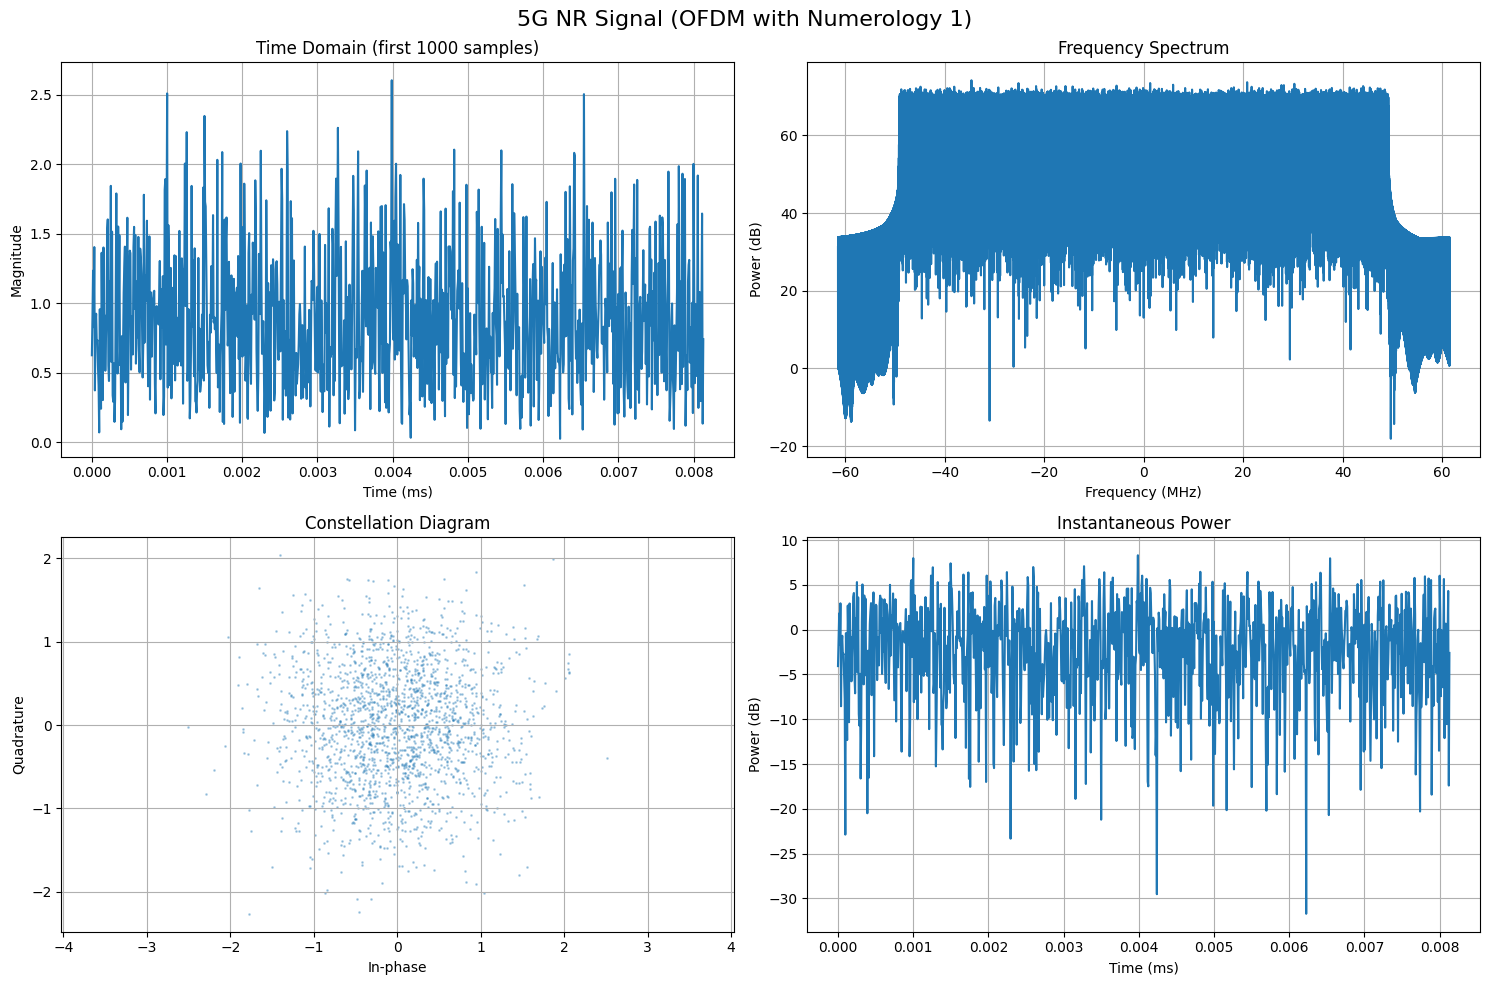

In [6]:
# Generate 5G NR signal
nr_result = generate_5g_signal(
    duration_ms=10.0,
    numerology=1,
    bandwidth_mhz=100.0,
    modulation_scheme='QPSK',
    carrier_freq=0.0,
    power_dbm=0.0,
    add_dmrs=True,
    device='cpu'
)

print_signal_properties(nr_result['metadata'])
plot_signal_analysis(
    nr_result['signal'],
    nr_result['metadata']['sample_rate'],
    '5G NR Signal (OFDM with Numerology 1)'
)

## 5. Comparison of All Standards

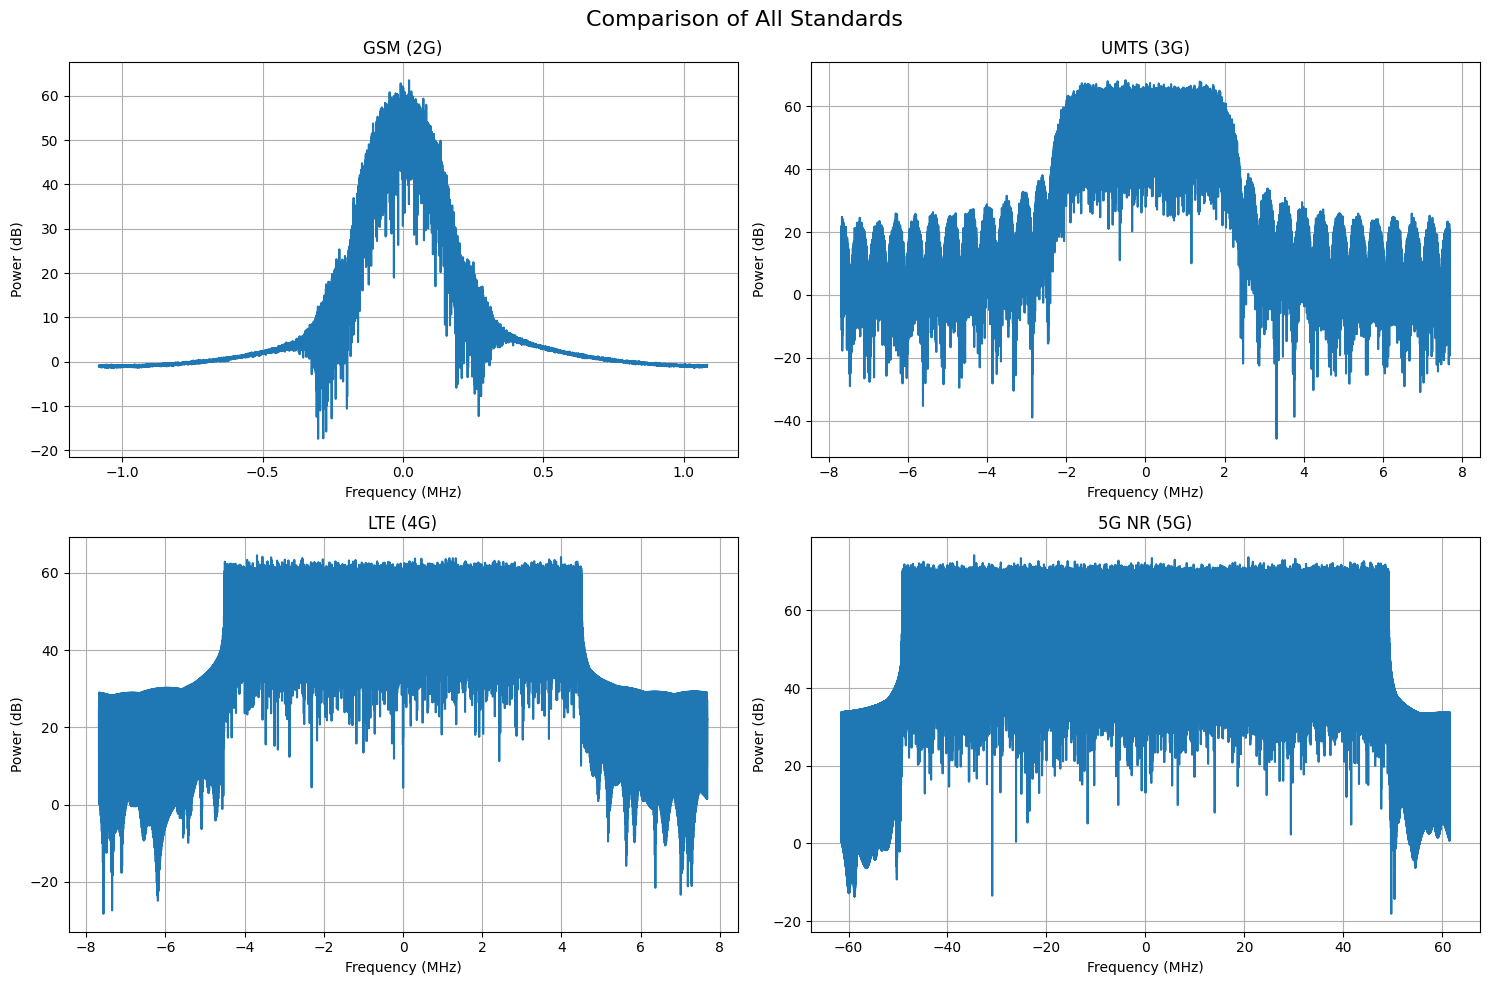


Summary Comparison:
Standard   PAPR (dB)    Bandwidth (MHz)    Sample Rate (MHz)   
GSM (2G)   0.00         0.20               2.17                
UMTS (3G)  5.22         5.00               15.36               
LTE (4G)   11.48        9.00               15.36               
5G NR (5G) 11.38        98.28              122.88              


In [7]:
# Compare spectra of all standards
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparison of All Standards', fontsize=16)

signals = [
    (gsm_result, 'GSM (2G)'),
    (umts_result, 'UMTS (3G)'),
    (lte_result, 'LTE (4G)'),
    (nr_result, '5G NR (5G)')
]

for idx, (result, label) in enumerate(signals):
    row = idx // 2
    col = idx % 2
    
    signal_np = result['signal'].cpu().numpy()
    sample_rate = result['metadata']['sample_rate']
    
    # Spectrum
    spectrum = np.fft.fftshift(np.fft.fft(signal_np))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(signal_np), 1/sample_rate)) / 1e6
    power_spectrum_db = 20 * np.log10(np.abs(spectrum) + 1e-12)
    
    axes[row, col].plot(freqs, power_spectrum_db)
    axes[row, col].set_xlabel('Frequency (MHz)')
    axes[row, col].set_ylabel('Power (dB)')
    axes[row, col].set_title(label)
    axes[row, col].grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print("\nSummary Comparison:")
print("=" * 80)
print(f"{'Standard':<10} {'PAPR (dB)':<12} {'Bandwidth (MHz)':<18} {'Sample Rate (MHz)':<20}")
print("=" * 80)

for result, label in signals:
    papr = result['metadata']['validation']['papr_db']
    bw = result['metadata']['validation']['bandwidth_hz'] / 1e6
    sr = result['metadata']['sample_rate'] / 1e6
    print(f"{label:<10} {papr:<12.2f} {bw:<18.2f} {sr:<20.2f}")

print("=" * 80)